#### Vamos a trabajar con nuestros CSV de animes, cargarlos, unirlos y limpiar los datos para su posterior análisis

In [51]:
import pandas as pd
import re
import numpy as np
import matplotlib.pyplot as plt

In [52]:
animes_1 = pd.read_csv('C:/Users/andre\Desktop\Curso_Data_Analytics\Tercera Semana\Proyecto Anime/animes y género.csv')
animes_2 = pd.read_csv('C:/Users/andre\Desktop\Curso_Data_Analytics\Tercera Semana\Proyecto Anime/anime_data.csv')

### Voy  a limpiar el dataframe animes_2 para dejar las columnas que voy  a utilizar y quitar películas y otros elementos que no son series

In [53]:
animes_1.columns

Index(['titulo', 'año', 'generos', 'rating'], dtype='object')

In [54]:
animes_2.columns

Index(['mal_id', 'titles', 'type', 'genre_1', 'genre_2', 'source', 'studios',
       'episodes', 'rating', 'score', 'audicence_rank', 'scored_by', 'rank',
       'members', 'favorites', 'synopsis', 'airing', 'genres', 'year',
       'season', 'status'],
      dtype='object')

In [55]:
#Nos quedamos con titles, genre_1 y 2
animes_2 = animes_2[['titles','score','genre_1','genre_2', 'episodes', 'year']]

Vamos a renombrar columnas para que coincidan con el otro dataframe

In [56]:
animes_2 = animes_2.rename(columns={'titles': 'titulo', 'score': 'rating', 'episodes': 'numero_episodios', 'year':'año'})

Unimos los valores de las columnas genre_1 y genre_2 en una y las eliminamos, para en un futuro unirlas al otro dataframe.

In [57]:
animes_2['generos'] = animes_2['genre_1'].fillna('') + ', ' + animes_2['genre_2'].fillna('')
animes_2['generos'] = animes_2['generos'].str.strip(', ')

In [58]:
animes_2.drop(['genre_1', 'genre_2'], axis=1, inplace=True)

Comprobamos que los valores de las columnas con el mismo nombre tienen el mismo formato para poder unirse:

In [59]:
animes_2.dtypes

titulo               object
rating              float64
numero_episodios    float64
año                 float64
generos              object
dtype: object

In [60]:
animes_2['año'] = animes_2['año'].astype('Int64')

In [61]:
animes_1.dtypes

titulo      object
año          int64
generos     object
rating     float64
dtype: object

Ya tenemos nuestros dos dataframes listos para unirse.

In [62]:
animes = pd.merge(animes_1,animes_2,on='titulo',how='outer',suffixes=('_1', '_2'))

Vamos a completar los valores nulos de las columnas para unificarlas:

In [63]:
animes['rating_2'] = animes['rating_2'].combine_first(animes['rating_1'])
animes['año_2'] = animes['año_2'].combine_first(animes['año_1'])
animes['generos_2'] = animes['generos_2'].combine_first(animes['generos_1'])
animes.drop(['generos_1', 'año_1','rating_1'], axis=1, inplace=True)

Quitamos las filas repetidas quedándonos con el primer valor

In [64]:
animes['n_missing'] = animes.isna().sum(axis=1)
animes = animes.sort_values(['titulo', 'n_missing'])
animes = animes.drop_duplicates(subset='titulo', keep='first')
animes = animes.reset_index(drop=True)
animes = animes.drop(columns=['n_missing'])

In [65]:
animes.columns

Index(['titulo', 'rating_2', 'numero_episodios', 'año_2', 'generos_2'], dtype='object')

In [66]:
animes = animes.rename(columns={'rating_2': 'puntuacion', 'año_2': 'año', 'generos_2': 'generos'})

Nos quedamos con los 2000 mejor valorados para el estudio:

In [67]:
animes_top2000 = animes.sort_values(by='puntuacion', ascending=False).head(2000).reset_index(drop=True)


In [68]:
animes_top2000

,titulo,puntuacion,numero_episodios,año,generos
0,Sousou no Frieren,9.38,28.0,2023.0,"Adventure, Drama"
1,Fullmetal Alchemist: Brotherhood,9.09,64.0,2009.0,"Action, Adventure"
2,Steins;Gate,9.07,24.0,2011.0,"Drama, Sci-Fi"
3,Gintama°,9.06,51.0,2015.0,"Action, Comedy"
4,Shingeki no Kyojin Season 3 Part 2,9.05,10.0,2019.0,"Action, Drama"
...,...,...,...,...,...
1995,Sasuga no Sarutobi,7.17,69.0,1982.0,"Adventure, Comedy"
1996,Mouretsu Pirates,7.16,26.0,2012.0,"Award Winning, Sci-Fi"
1997,Ookami-san to Shichinin no Nakama-tachi,7.16,12.0,2010.0,"Comedy, Romance"
1998,Sentou Mecha Xabungle,7.16,50.0,1982.0,"Action, Sci-Fi"


Vamos a hacer un reescaling con la puntuación para una mejor valoración sobre 100, poninedo como 0 el valor más bajo de la tabla y 100 el más alto

In [69]:
min_rating = 7.16
max_rating = 9.38

animes_top2000['rating_100'] = (animes_top2000['puntuacion'] - min_rating) / (max_rating - min_rating) * 100
animes_top2000['rating_100'] = animes_top2000['rating_100'].round(2)

In [70]:
animes_top2000

,titulo,puntuacion,numero_episodios,año,generos,rating_100
0,Sousou no Frieren,9.38,28.0,2023.0,"Adventure, Drama",100.00
1,Fullmetal Alchemist: Brotherhood,9.09,64.0,2009.0,"Action, Adventure",86.94
2,Steins;Gate,9.07,24.0,2011.0,"Drama, Sci-Fi",86.04
3,Gintama°,9.06,51.0,2015.0,"Action, Comedy",85.59
4,Shingeki no Kyojin Season 3 Part 2,9.05,10.0,2019.0,"Action, Drama",85.14
...,...,...,...,...,...,...
1995,Sasuga no Sarutobi,7.17,69.0,1982.0,"Adventure, Comedy",0.45
1996,Mouretsu Pirates,7.16,26.0,2012.0,"Award Winning, Sci-Fi",0.00
1997,Ookami-san to Shichinin no Nakama-tachi,7.16,12.0,2010.0,"Comedy, Romance",0.00
1998,Sentou Mecha Xabungle,7.16,50.0,1982.0,"Action, Sci-Fi",0.00


Vamos a analizar nuestro dataframe

In [71]:
animes_top2000.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   titulo            2000 non-null   object 
 1   puntuacion        2000 non-null   float64
 2   numero_episodios  1940 non-null   float64
 3   año               1980 non-null   Float64
 4   generos           1986 non-null   object 
 5   rating_100        2000 non-null   float64
dtypes: Float64(1), float64(3), object(2)
memory usage: 95.8+ KB


Veamos los valores nulos

In [72]:
animes_top2000.isnull().sum()

titulo               0
puntuacion           0
numero_episodios    60
año                 20
generos             14
rating_100           0
dtype: int64

Veamos si esos nulos son muchos o pocos respecto al total

In [73]:
animes_top2000.isnull().sum()/animes_top2000.shape[0]

titulo              0.000
puntuacion          0.000
numero_episodios    0.030
año                 0.010
generos             0.007
rating_100          0.000
dtype: float64

Son prácticamente despreciables, así que podemos trabajar con ellos.  Pero en la columna de numero_episodios voy  a quedarme con aquellos que tengan más de 1, para así eliminar las películas.

In [74]:
animes_top2000 = animes_top2000.dropna(subset=['numero_episodios'])
animes_top2000 = animes_top2000[animes_top2000['numero_episodios'] > 1]
animes_top2000

,titulo,puntuacion,numero_episodios,año,generos,rating_100
0,Sousou no Frieren,9.38,28.0,2023.0,"Adventure, Drama",100.00
1,Fullmetal Alchemist: Brotherhood,9.09,64.0,2009.0,"Action, Adventure",86.94
2,Steins;Gate,9.07,24.0,2011.0,"Drama, Sci-Fi",86.04
3,Gintama°,9.06,51.0,2015.0,"Action, Comedy",85.59
4,Shingeki no Kyojin Season 3 Part 2,9.05,10.0,2019.0,"Action, Drama",85.14
...,...,...,...,...,...,...
1995,Sasuga no Sarutobi,7.17,69.0,1982.0,"Adventure, Comedy",0.45
1996,Mouretsu Pirates,7.16,26.0,2012.0,"Award Winning, Sci-Fi",0.00
1997,Ookami-san to Shichinin no Nakama-tachi,7.16,12.0,2010.0,"Comedy, Romance",0.00
1998,Sentou Mecha Xabungle,7.16,50.0,1982.0,"Action, Sci-Fi",0.00


Con estos datos podemos comenzar el análisis.

In [101]:
animes_top2000.describe().round(2).T

,count,mean,std,min,25%,50%,75%,max
puntuacion,1507.0,7.72,0.43,7.16,7.36,7.61,8.0,9.38
numero_episodios,1507.0,28.01,57.44,2.0,12.0,13.0,26.0,1787.0
año,1493.0,2007.37,12.14,1970.0,2000.0,2010.0,2017.0,2024.0
rating_100,1507.0,25.25,19.52,0.0,9.01,20.27,38.06,100.0


### ¿Qué podemos sacar de aquí? 
- Puntuación: 

      Desviación estándar baja (0.43). Las puntuaciones son bastante consistentes, sin mucha variabilidad.
- Número de episodios: 

      Aquí si que tenemos varios parámetros interesantes:

      Media: 28 episodios, pero con una desviación muy alta (57), lo que queire decir que hay mucha variación entre series cortas y largas.

      Percentiles:

            25% ≤ 12 episodios , muchas series cortas.

            75% ≤ 26 episodios , la mayoría son de duración estándar (1 o 2 temporadas).

      Máximo: 1787 episodios, lo cual nos indica que hay algunos casos extremos (series largas como One Piece).

      Conclusión: predominan las series cortas, pero existen pocos animes muy largos que distorsionan la media.
- Año

      Media: 2007, así que la mayoría de animes en el dataset son de los 2000s y 2010s.

      Rango: 1970–2024, abarca varias generaciones, pero la mediana (2010) indica concentración en los últimos 15 años.

      Conclusión: el anime moderno domina el top; los clásicos son minoría.
- Rating (sobre 100)

      Media: 25.25 con alta desviación (19.52) → hay mucha variabilidad en popularidad.

      Distribución sesgada: el 75% tiene rating ≤ 38, lo que sugiere que solo unos pocos animes son extremadamente populares.
- Conclusión general:

      Los animes mejor valorados tienden a tener buenas puntuaciones y duración moderada.

      El top está compuesto mayoritariamente por producciones recientes (post-2000).

      Series largas son excepciones, pero impactan mucho en la media de episodios.

      Popularidad (rating_100) está muy concentrada: pocos animes concentran la mayoría del interés del público.
      

### Vamos a empezar a comparar parámetros

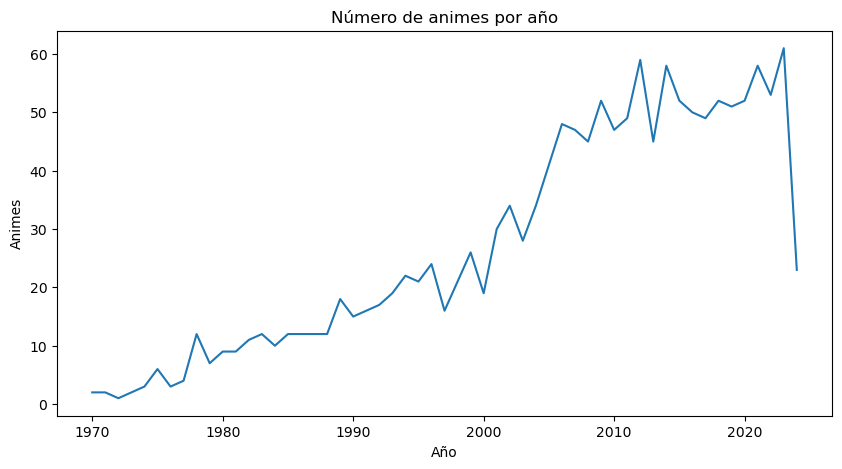

In [76]:


animes_top2000['año'].value_counts().sort_index().plot(
    kind='line', figsize=(10,5), title='Número de animes por año'
)
plt.xlabel('Año')
plt.ylabel('Animes')
plt.show()

In [77]:
animes_top2000["generos"].nunique()

97

In [78]:
#Está tomando cada string como un género diferente ( "comedy, horror" lo cuenta como uno) y eso no me interesa. Vamos a cambiarlo

# 1. Dividir cada celda en una lista de géneros
animes_top2000['generos'] = animes_top2000['generos'].str.split(',')

# 2. Quitar espacios extra (por ejemplo " Drama" - "Drama")
animes_top2000['generos'] = animes_top2000['generos'].apply(lambda x: [g.strip() for g in x])

# 3. Usar explode en la columna para que cada género tenga su propia fila
animes_exp_gen = animes_top2000.explode('generos')

# 4. Ahora podemos contar géneros correctamente:
conteo_generos = animes_exp_gen['generos'].value_counts()

print(conteo_generos.head(10))  # Los 10 géneros más comunes


generos
Action           613
Comedy           520
Adventure        376
Drama            334
Fantasy          201
Romance          196
Mystery          103
Sports            72
Sci-Fi            71
Slice of Life     65
Name: count, dtype: int64


### Ahora tenemos los géneros separados en una lista y podemos usar conteo_generos para nuestras estadísticas

In [79]:

# Hacemos un .groupby para ver cuantos animes hay por año y género
conteo_generos_por_año = (animes_exp_gen.groupby(['año', 'generos']).size().reset_index(name='cantidad'))
# Ver los primeros resultados
print(conteo_generos_por_año.head())

      año    generos  cantidad
0  1970.0  Adventure         1
1  1970.0     Comedy         1
2  1970.0      Drama         1
3  1970.0     Sports         1
4  1971.0     Action         1


### Vamos a ver el top 5 de géneros más numerosos y compararlos en una gráfica:


Top 5 géneros más numerosos: ['Action', 'Comedy', 'Adventure', 'Drama', 'Fantasy']


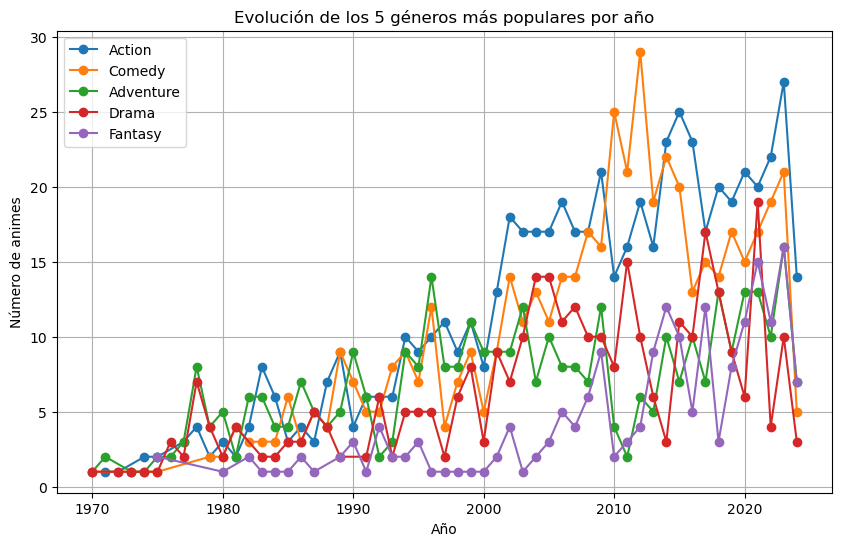

In [118]:

# Calculamos los géneros más populares en total
top_generos = (animes_exp_gen['generos'].value_counts().head(5).index.tolist())
print("Top 5 géneros más numerosos:", top_generos)
# Graficar evolución por año de los top 5 géneros
plt.figure(figsize=(10,6))
for g in top_generos:
    data_g = conteo_generos_por_año[conteo_generos_por_año['generos'] == g]
    plt.plot(data_g['año'], data_g['cantidad'], marker='o', label=g)

plt.title('Evolución de los 5 géneros más populares por año')
plt.xlabel('Año')
plt.ylabel('Número de animes')
plt.legend()
plt.grid(True)
plt.show()

### En esta gráfica podemos apreciar cómo varían los 5 generos más populares a lo largo de los años. 
- Hasta los 90, más o menos había el mismo número de animes por género.
- A partir de los 90 empiezan a destacar los géneros de acción, comedia y aventuras gracias a la popularidad de series como Dragon Ball y Detective Conan.
- En los 2000 es el gran boom de las series de acción, enfocada sobre todo a un público masculino y joven (shonen), con series como One Piece, Naruto, Hunter x Hunter... y donde el anime cobra una popularidad nunca vista antes a nivel mundial.
- El drama es popular, pero menos que el resto quizá porque está enfocado  a un público más adulto.


### Vamos a ver la evolución temporal del anime

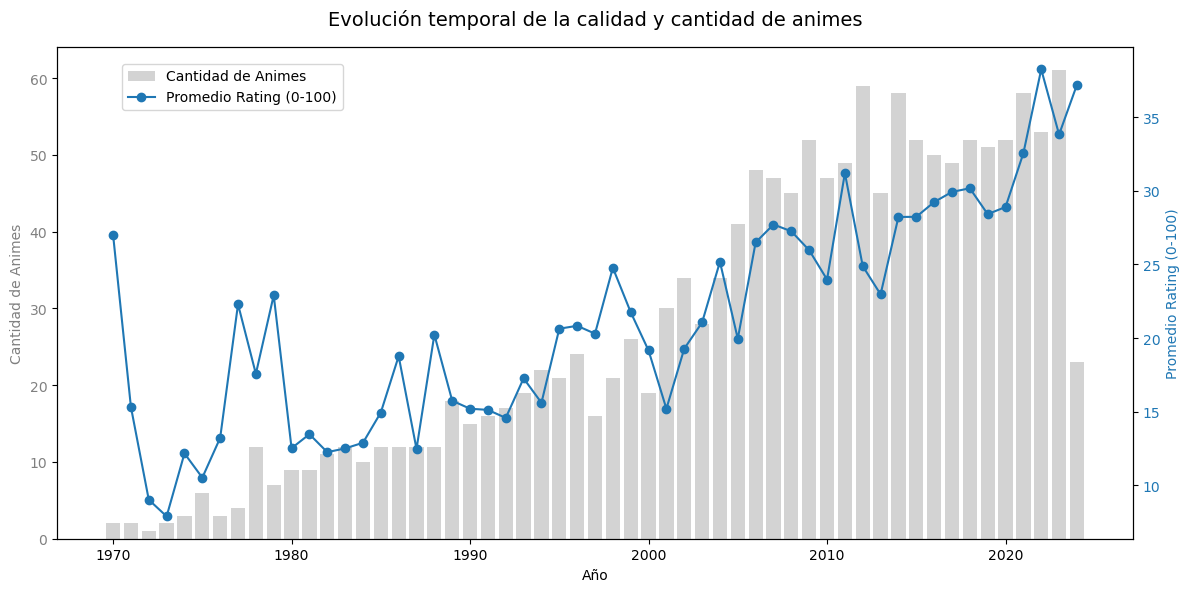

In [95]:
#Nos quedamos con las filas que tengan los datos a analizar, año y rating_100
animes_rating = animes_top2000.dropna(subset=['año', 'rating_100'])
#Agrupar por año y calcular métricas
evolucion_animes = animes_rating.groupby('año').agg(promedio_rating=('rating_100', 'mean'),cantidad_animes=('titulo', 'count')).reset_index()
fig, ax1 = plt.subplots(figsize=(12,6))

# Barras: cantidad de animes por año
ax1.bar(evolucion_animes['año'], evolucion_animes['cantidad_animes'], 
        color='lightgray', label='Cantidad de Animes')
ax1.set_xlabel('Año')
ax1.set_ylabel('Cantidad de Animes', color='gray')
ax1.tick_params(axis='y', labelcolor='gray')

# Eje secundario para promedio de rating
ax2 = ax1.twinx()
ax2.plot(evolucion_animes['año'], evolucion_animes['promedio_rating'], 
         color='tab:blue', marker='o', label='Promedio Rating (0-100)')
ax2.set_ylabel('Promedio Rating (0-100)', color='tab:blue')
ax2.tick_params(axis='y', labelcolor='tab:blue')

# Título y leyenda
fig.suptitle('Evolución temporal de la calidad y cantidad de animes', fontsize=14)
fig.tight_layout()
fig.legend(loc='upper left', bbox_to_anchor=(0.1,0.9))

plt.show()

### ¿Qué observamos?
- Los animes modernos están en general mejor valorados. Esto puede deberse a las mejoras en la animación, o que haya una mayoría de público joven que encuentre las series antiguas menos atractivas. Sería interesante verlo en otro proyecto futuro centrado en la audiencia.
- Hay animes antiguos que destacan bastante sobre el resto.
- La pandemia mundial (años 2019-2020) repercutió de manera positiva tanto en la calidad como en el número de animes, al contrario que la crisis de 2008, que mantuvo el número de series estable pero de peor calidad.

### Vamos a ver ahora la cantidad de episodios y la calidad:

         rango_duracion       mean  count
2  Medianos (14-26 eps)  28.572058    379
0      Cortos (≤13 eps)  25.242200    809
1      Largos (>26 eps)  21.310721    319


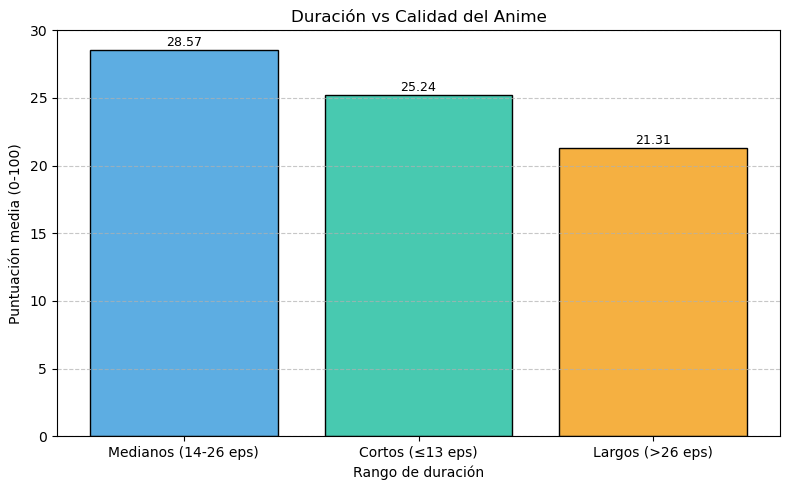

In [98]:
#Limpiar filas sin número de episodios o puntuación
animes_epis_punt = animes_top2000.dropna(subset=['numero_episodios', 'rating_100'])

# Creamos una función para clasificar los animes en rangos de duración:
def clasificar_duracion(n):
    if n <= 13:
        return 'Cortos (≤13 eps)'
    elif n <= 26:
        return 'Medianos (14-26 eps)'
    else:
        return 'Largos (>26 eps)'

animes_epis_punt['rango_duracion'] = animes_epis_punt['numero_episodios'].apply(clasificar_duracion)

# Calcular la media de puntuación por rango
promedios_duracion = (animes_epis_punt.groupby('rango_duracion')['rating_100'].agg(['mean', 'count']).reset_index().sort_values('mean', ascending=False))

print(promedios_duracion)

# Hacer la gráfica
plt.figure(figsize=(8,5))
bars = plt.bar(promedios_duracion['rango_duracion'], promedios_duracion['mean'],
               color=['#5DADE2', '#48C9B0', '#F5B041'], edgecolor='black')

plt.title('Duración vs Calidad del Anime')
plt.xlabel('Rango de duración')
plt.ylabel('Puntuación media (0-100)')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Mostrar el promedio encima de cada barra
for bar, valor in zip(bars, promedios_duracion['mean']):
    plt.text(bar.get_x() + bar.get_width()/2, valor + 0.05, f"{valor:.2f}", 
             ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()